<a href="https://colab.research.google.com/github/Hala-sala7/adult-income-dataset/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult Income Classification Project

## Overview

In this project, I will use the **Adult Income Dataset** to predict whether a person's income is **>50K** or **<=50K** per year.

The dataset includes information such as age, education, occupation, marital status, working hours, and income category.

This project will include data loading, cleaning, preprocessing, model training, and evaluation.

This is a **classification problem** because the target variable has two categories: **>50K** and **<=50K**.

## Import Libraries

In this section, I import the libraries needed for data analysis, visualization, preprocessing, model training, and evaluation.

In [1]:
from google.colab import drive

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression

## Load the Dataset

The dataset is loaded from a CSV file into a Pandas DataFrame.  
Then, I display the first few rows to understand the structure of the data.

In [3]:
drive.mount('/content/data')

Drive already mounted at /content/data; to attempt to forcibly remount, call drive.mount("/content/data", force_remount=True).


In [4]:
fname='/content/data/MyDrive/AXSOSACADEMY/05-IntermediateML/Week17/adult.csv'

In [5]:
df = pd.read_csv(fname)

In [6]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


## Explore the Data

In this step, I explore the dataset by checking the number of rows and columns, column names, data types, and basic information about the dataset.

In [7]:
# Display the shape of the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 48842
Number of columns: 15


In [8]:
# Display column names
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [9]:
# Display general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [10]:
# Remove redundant education column
df = df.drop('education', axis=1)

# Check the updated columns
df.columns

Index(['age', 'workclass', 'fnlwgt', 'educational-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [11]:
# Display summary statistics for numerical columns
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## Numerical Features Summary

The numerical statistics show that the values in the dataset are generally reasonable.

The `age` column ranges from 17 to 90 years old, with an average age of about 38.6. This means the dataset includes adults from different age groups.

The `educational-num` column ranges from 1 to 16. This column represents the education level as a number, where higher values usually indicate higher education levels.

The `hours-per-week` column ranges from 1 to 99 hours, with an average of about 40 hours per week. This makes sense because many people work around 40 hours weekly.

The `capital-gain` and `capital-loss` columns contain many zero values, as shown by the 25%, 50%, and 75% values being 0. This means that most people in the dataset did not report investment gains or losses. However, the maximum values are high, which shows that a small number of people have large capital gains or losses.

The `fnlwgt` column represents a statistical sampling weight. It is less directly interpretable than the other numerical features, but it is part of the original dataset.

Overall, the numerical features look valid, but some columns such as `capital-gain` and `capital-loss` are skewed because most values are 0 while a few values are very large.


## Capital Gain and Capital Loss Visualization

This visualization compares the average `capital-gain` and `capital-loss` values for each income category.

The goal is to understand whether people with income `>50K` tend to have higher capital gains or losses compared to people with income `<=50K`.

In [12]:
# Calculate the average capital-gain and capital-loss for each income category
capital_summary = df.groupby('income')[['capital-gain', 'capital-loss']].mean()

capital_summary

,capital-gain,capital-loss
income,,
<=50K,147.010308,54.151931
>50K,4042.239497,193.528964


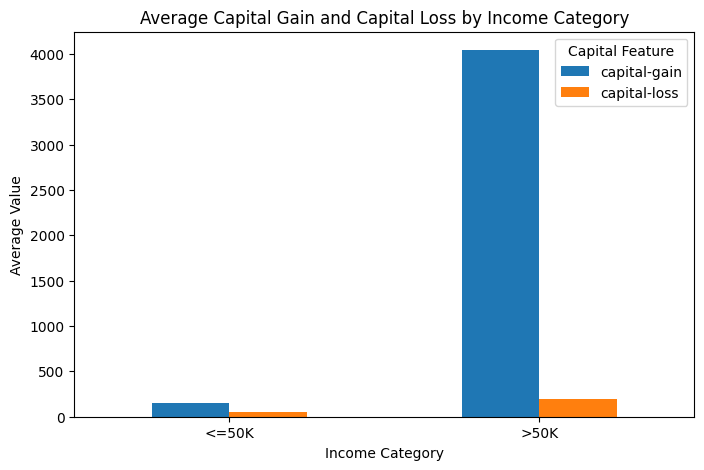

In [13]:
# Visualize average capital-gain and capital-loss by income category

capital_summary.plot(kind='bar', figsize=(8, 5))

plt.title('Average Capital Gain and Capital Loss by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Capital Feature')
plt.show()

### Capital Gain and Capital Loss Insight

This chart shows that people with income `>50K` have a much higher average `capital-gain` compared to people with income `<=50K`.

The difference in `capital-gain` is very large, which suggests that people in the higher income group are more likely to have financial gains from investments or selling assets.

The average `capital-loss` is also slightly higher for the `>50K` group, but the difference is much smaller than the difference in `capital-gain`.

This means that `capital-gain` may be an important feature for predicting whether a person's income is greater than 50K.

In [14]:
# Display summary statistics for categorical columns
df.describe(include='object')

,workclass,marital-status,occupation,relationship,race,gender,native-country,income
count,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,7,15,6,5,2,42,2
top,Private,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,22379,6172,19716,41762,32650,43832,37155


## Categorical Features Summary

The categorical summary shows that the dataset contains several categorical features such as `workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `gender`, `native-country`, and `income`.

The `income` column is the target variable and has 2 unique classes: `<=50K` and `>50K`.

The most common workclass is `Private`, which appears 33,906 times.  
The most common education level is `HS-grad`, which appears 15,784 times.  
The most common marital status is `Married-civ-spouse`, and the most common occupation is `Prof-specialty`.

The `native-country` column has 42 unique values, but the most common country is `United-States`, which appears 43,832 times. This means most records in the dataset are from the United States.

The target variable is imbalanced because the most common income category is `<=50K`, which appears 37,155 times. This means there are more people earning `<=50K` than people earning `>50K`.

In [15]:
# Check normal missing values
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0
capital-gain,0


In [16]:
# Check duplicated rows
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 52


In [17]:
# Remove duplicated rows
df = df.drop_duplicates()

In [18]:
(df == '?').sum()

,0
age,0
workclass,2795
fnlwgt,0
educational-num,0
marital-status,0
occupation,2805
relationship,0
race,0
gender,0
capital-gain,0


In [19]:
# Display rows with '?' in any column
rows_with_question_marks = df[df.eq('?').any(axis=1)]

print("Number of rows with question marks:", rows_with_question_marks.shape[0])

rows_with_question_marks.head(20)

Number of rows with question marks: 3615


,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
4,18,?,103497,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,?,227026,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,?,299831,9,Married-civ-spouse,?,Husband,White,Male,0,0,35,United-States,<=50K
19,40,Private,85019,16,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,45,?,>50K
22,72,?,132015,4,Divorced,?,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,?,191846,9,Married-civ-spouse,?,Husband,White,Male,0,0,40,United-States,<=50K
65,41,Private,109912,13,Never-married,Other-service,Not-in-family,White,Female,0,0,40,?,<=50K
75,17,?,165361,6,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K
83,44,Self-emp-inc,223881,9,Married-civ-spouse,Craft-repair,Husband,White,Male,99999,0,50,?,>50K
89,41,?,38434,14,Married-civ-spouse,?,Wife,White,Female,7688,0,10,United-States,>50K


In [20]:
# Replace '?' with NaN
df = df.replace('?', np.nan)

# Check missing values after replacement
df.isnull().sum()

,0
age,0
workclass,2795
fnlwgt,0
educational-num,0
marital-status,0
occupation,2805
relationship,0
race,0
gender,0
capital-gain,0


In [21]:
# Check target variable distribution
df['income'].value_counts()

,count
income,
<=50K,37109
>50K,11681


In [22]:
# Check target variable percentage
df['income'].value_counts(normalize=True) * 100

,proportion
income,
<=50K,76.058619
>50K,23.941381


### it's impalanced dataset


In [23]:
# Display unique values count for each column
df.nunique()

,0
age,74
workclass,8
fnlwgt,28523
educational-num,16
marital-status,7
occupation,14
relationship,6
race,5
gender,2
capital-gain,123


In [24]:
# Display categorical columns
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'gender', 'native-country', 'income'],
      dtype='object')

In [25]:
# check the cardinality
df[categorical_cols].nunique().sort_values(ascending=False)

,0
native-country,41
occupation,14
workclass,8
marital-status,7
relationship,6
race,5
gender,2
income,2


In [26]:
# Display numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

## High Cardinality Decision

The `native-country` column has the highest cardinality among the categorical features, with 41 unique values. However, this number is still manageable for encoding, so I decided not to remove it.

Instead, I will keep `native-country` because it may contain useful information related to income prediction.

The `fnlwgt` column is numerical and has many unique values, but it is not considered a categorical high-cardinality feature. It represents a statistical sampling weight, so it may be less interpretable than other features.

In [27]:
# Check unique values for each categorical column

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("=" * 50)
    print(f"Column: {col}")
    print("Number of unique values:", df[col].nunique())
    print(df[col].sort_values().unique())

Column: workclass
Number of unique values: 8
['Federal-gov' 'Local-gov' 'Never-worked' 'Private' 'Self-emp-inc'
 'Self-emp-not-inc' 'State-gov' 'Without-pay' nan]
Column: marital-status
Number of unique values: 7
['Divorced' 'Married-AF-spouse' 'Married-civ-spouse'
 'Married-spouse-absent' 'Never-married' 'Separated' 'Widowed']
Column: occupation
Number of unique values: 14
['Adm-clerical' 'Armed-Forces' 'Craft-repair' 'Exec-managerial'
 'Farming-fishing' 'Handlers-cleaners' 'Machine-op-inspct' 'Other-service'
 'Priv-house-serv' 'Prof-specialty' 'Protective-serv' 'Sales'
 'Tech-support' 'Transport-moving' nan]
Column: relationship
Number of unique values: 6
['Husband' 'Not-in-family' 'Other-relative' 'Own-child' 'Unmarried' 'Wife']
Column: race
Number of unique values: 5
['Amer-Indian-Eskimo' 'Asian-Pac-Islander' 'Black' 'Other' 'White']
Column: gender
Number of unique values: 2
['Female' 'Male']
Column: native-country
Number of unique values: 41
['Cambodia' 'Canada' 'China' 'Columbia'

# Exploratory Visualizations

In this section, I create exploratory visualizations to better understand the dataset and identify trends between different features and the target variable `income`.

The goal is to explore how income is related to demographic, education, work, and financial features.

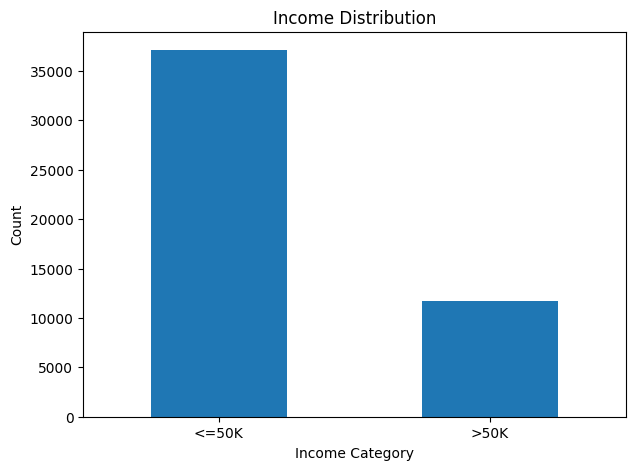

In [28]:
# Income distribution

income_counts = df['income'].value_counts()

plt.figure(figsize=(7, 5))
income_counts.plot(kind='bar')

plt.title('Income Distribution')
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Insight

The chart shows that the `<=50K` income category appears more frequently than the `>50K` category.

This means the target variable is imbalanced, and the model may learn the majority class more easily than the minority class.

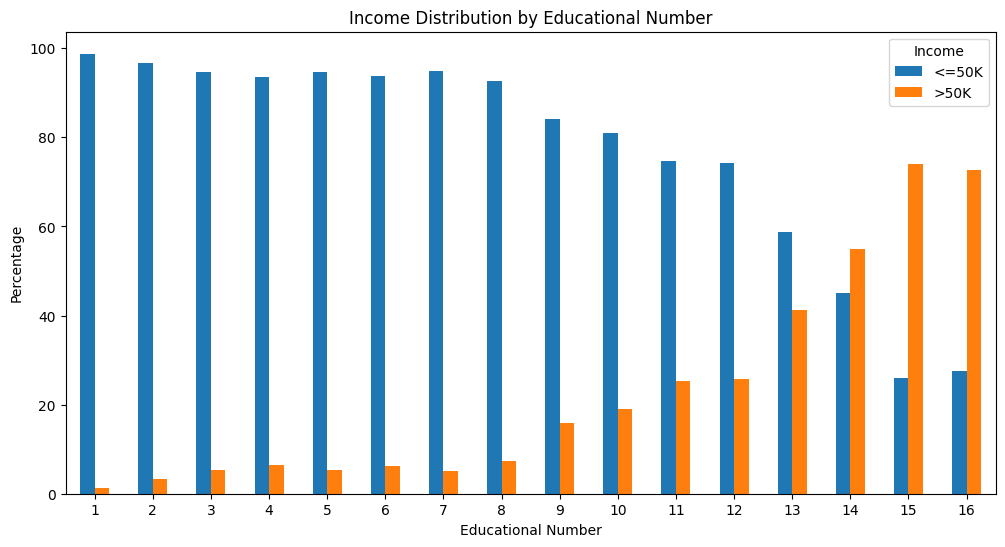

In [29]:
# Education level (numerical) vs income
education_num_income = pd.crosstab(df['educational-num'], df['income'], normalize='index') * 100

education_num_income.plot(kind='bar', figsize=(12, 6))

plt.title('Income Distribution by Educational Number')
plt.xlabel('Educational Number')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Income')
plt.show()

### Educational Number and Income Insight

This chart shows the percentage distribution of income categories for each value of `educational-num`.

The `educational-num` feature represents education level as an ordered numerical value, where higher numbers usually indicate higher education levels.

Lower educational numbers are mostly associated with the `<=50K` income category.

As the educational number increases, the percentage of people earning `>50K` also tends to increase.

This shows a clear relationship between education level and income. Therefore, `educational-num` is likely an important feature for predicting income.

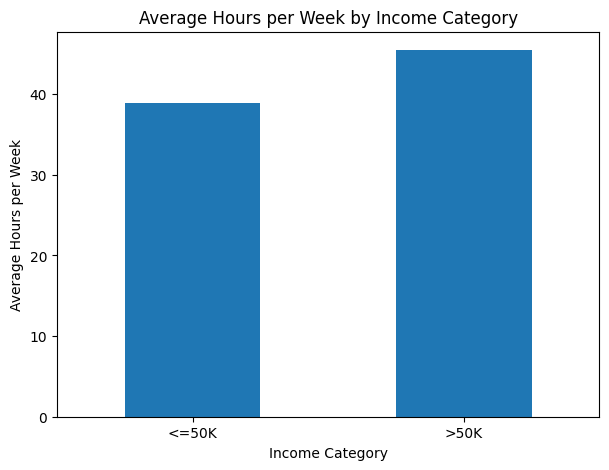

In [30]:
# Average hours per week by income category

hours_income = df.groupby('income')['hours-per-week'].mean()

plt.figure(figsize=(7, 5))
hours_income.plot(kind='bar')

plt.title('Average Hours per Week by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Average Hours per Week')
plt.xticks(rotation=0)
plt.show()

### Working Hours and Income Insight

This chart shows the average weekly working hours for each income category.

People with income `>50K` work more hours per week on average compared to people with income `<=50K`.

The `<=50K` group works around 39 hours per week on average, while the `>50K` group works around 45 hours per week on average.

This suggests that weekly working hours may be related to income level. People who work more hours may have a higher chance of earning more than 50K.

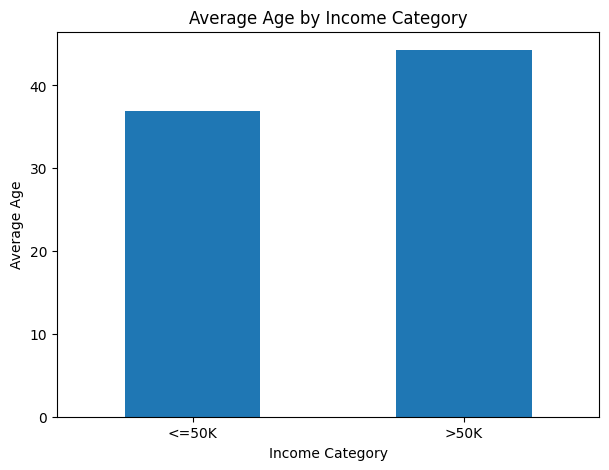

In [31]:
# Average age by income category

age_income = df.groupby('income')['age'].mean()

plt.figure(figsize=(7, 5))
age_income.plot(kind='bar')

plt.title('Average Age by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Average Age')
plt.xticks(rotation=0)
plt.show()

### Age and Income Insight

This chart shows the average age for each income category.

People with income `>50K` are older on average compared to people with income `<=50K`.

The `<=50K` group has an average age of around 37 years, while the `>50K` group has an average age of around 44 years.

This suggests that age may be related to income level. Older people may have more work experience, which can increase their chances of earning more than 50K.

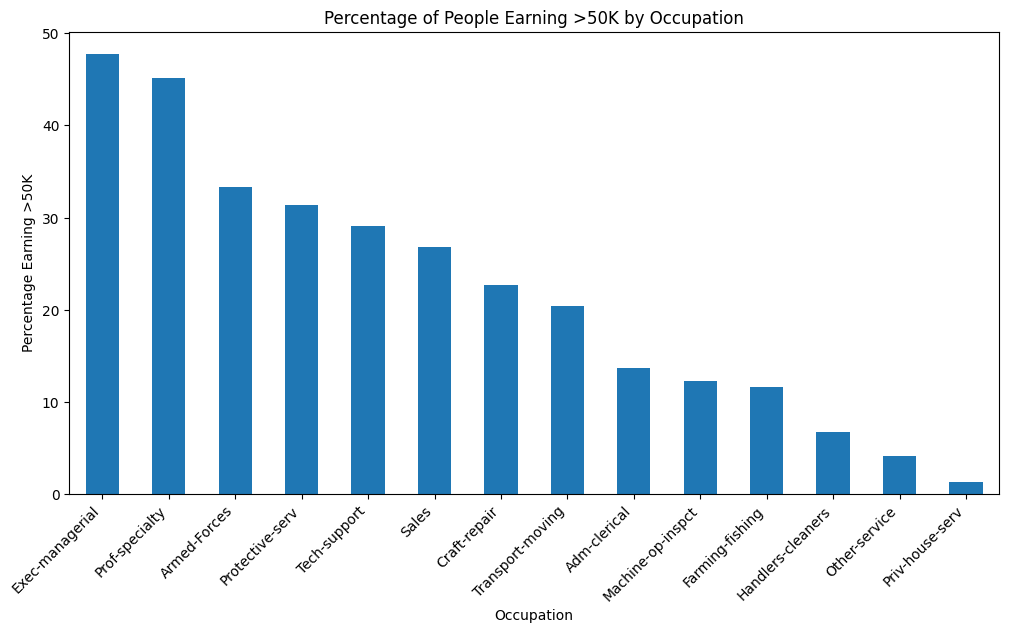

In [32]:
# Percentage of >50K income by occupation

occupation_income = pd.crosstab(df['occupation'], df['income'], normalize='index') * 100

occupation_income['>50K'].sort_values(ascending=False).plot(kind='bar', figsize=(12, 6))

plt.title('Percentage of People Earning >50K by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Percentage Earning >50K')
plt.xticks(rotation=45, ha='right')
plt.show()

### Occupation and Income Insight

This chart shows the percentage of people earning `>50K` within each occupation.

The occupations with the highest percentage of people earning `>50K` are `Exec-managerial` and `Prof-specialty`. This means that people in managerial and professional jobs are more likely to have higher income.

Other occupations such as `Armed-Forces`, `Protective-serv`, `Tech-support`, and `Sales` also show moderate percentages of people earning more than 50K.

On the other hand, occupations such as `Handlers-cleaners`, `Other-service`, and `Priv-house-serv` have very low percentages of people earning `>50K`.

This suggests that occupation is an important feature for predicting income because job type is strongly related to earning potential.

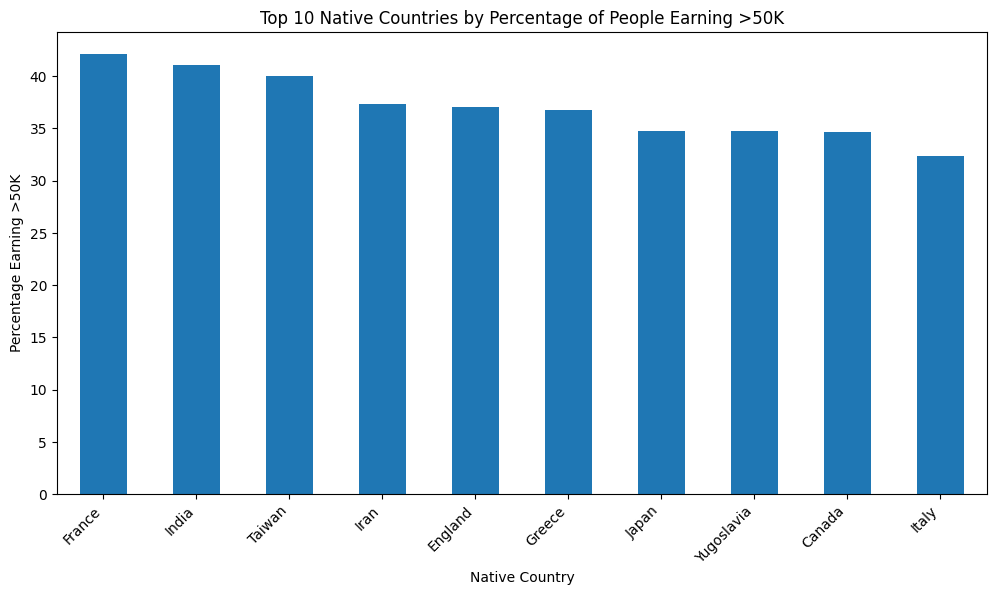

In [33]:
# Percentage of >50K income by native country

country_income = pd.crosstab(df['native-country'], df['income'], normalize='index') * 100

country_income['>50K'].sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12, 6))

plt.title('Top 10 Native Countries by Percentage of People Earning >50K')
plt.xlabel('Native Country')
plt.ylabel('Percentage Earning >50K')
plt.xticks(rotation=45, ha='right')
plt.show()

### Native Country and Income Insight

This chart shows the top 10 native countries with the highest percentage of people earning `>50K`.

France, India, Taiwan, Iran, England, Greece, Japan, Yugoslavia, Canada, and Italy appear among the countries with the highest percentages of people earning more than 50K.

This suggests that `native-country` may have some relationship with income level.

However, this result should be interpreted carefully because some countries may have a small number of records in the dataset. A high percentage does not always mean that many people from that country earn more than 50K; it may be affected by a small sample size.

Therefore, `native-country` may provide useful information, but it should be considered together with stronger features such as education, occupation, working hours, age, and capital gain.

In [34]:
# Check sample size for the top 10 countries shown in the chart
top_10_countries = country_income['>50K'].sort_values(ascending=False).head(10).index

df[df['native-country'].isin(top_10_countries)]['native-country'].value_counts()

,count
native-country,
Canada,182
India,151
England,127
Italy,105
Japan,92
Taiwan,65
Iran,59
Greece,49
France,38


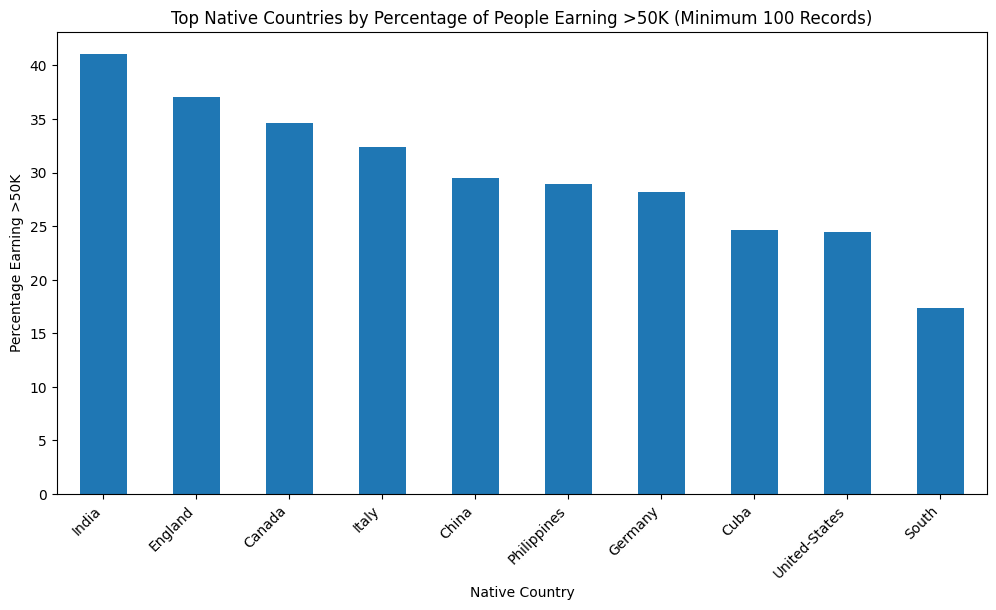

In [35]:
# Count records for each native country
country_counts = df['native-country'].value_counts()

# Keep only countries with at least 100 records
countries_with_enough_data = country_counts[country_counts >= 100].index

# Filter the dataframe
filtered_country_df = df[df['native-country'].isin(countries_with_enough_data)]

# Calculate percentage of >50K by native country
country_income_filtered = pd.crosstab(
    filtered_country_df['native-country'],
    filtered_country_df['income'],
    normalize='index'
) * 100

# Plot top 10 countries with enough records
country_income_filtered['>50K'].sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Top Native Countries by Percentage of People Earning >50K (Minimum 100 Records)')
plt.xlabel('Native Country')
plt.ylabel('Percentage Earning >50K')
plt.xticks(rotation=45, ha='right')
plt.show()

### Native Country and Income Insight

This chart shows the native countries with the highest percentage of people earning `>50K`, after filtering the data to include only countries with at least 100 records.

This filtering makes the analysis more reliable because countries with very small sample sizes can produce misleading percentages.

After filtering, countries such as India, England, Canada, Italy, China, Philippines, Germany, Cuba, United States, and South appear among the countries with higher percentages of people earning more than 50K.

This suggests that `native-country` may have some relationship with income level. However, it should still be interpreted carefully because the dataset is highly dominated by records from the United States.

Therefore, `native-country` may provide useful information for the model, but it should be considered together with stronger features such as education, occupation, age, working hours, and capital gain.

# Modeling

In [36]:
# Separate features and target
X = df.drop('income', axis=1)
y = df['income']

# Drop the statistical sampling weight (not predictive, adds noise)
X = X.drop('fnlwgt', axis=1)

In [37]:
# split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
def fill_missing_by_group(X_train, X_test, target_col, group_cols):
    """
    Fill missing values in a categorical column using the most frequent value
    within groups defined by other columns.

    The mapping is learned from X_train only to avoid data leakage.
    """

    X_train = X_train.copy()
    X_test = X_test.copy()

    # Global mode from training data as fallback
    global_mode = X_train[target_col].mode()[0]

    # Create group-based mode mapping using training data only
    group_mode = (
        X_train
        .dropna(subset=[target_col])
        .groupby(group_cols)[target_col]
        .agg(lambda x: x.mode()[0])
    )

    def impute_row(row):
        if pd.isna(row[target_col]):
            key = tuple(row[col] for col in group_cols)

            # If only one group column, key should not be tuple
            if len(group_cols) == 1:
                key = key[0]

            return group_mode.get(key, global_mode)

        return row[target_col]

    # Apply imputation to train and test
    X_train[target_col] = X_train.apply(impute_row, axis=1)
    X_test[target_col] = X_test.apply(impute_row, axis=1)

    return X_train, X_test

In [39]:
# Make copies before custom imputation
X_train_custom = X_train.copy()
X_test_custom = X_test.copy()

# Impute occupation using similar workclass and education level
X_train_custom, X_test_custom = fill_missing_by_group(
    X_train_custom,
    X_test_custom,
    target_col='occupation',
    group_cols=['workclass', 'educational-num']
)

# Impute workclass using occupation and education level
X_train_custom, X_test_custom = fill_missing_by_group(
    X_train_custom,
    X_test_custom,
    target_col='workclass',
    group_cols=['occupation', 'educational-num']
)

# Impute native-country using race
X_train_custom, X_test_custom = fill_missing_by_group(
    X_train_custom,
    X_test_custom,
    target_col='native-country',
    group_cols=['race']
)

## Custom Missing Value Imputation

Instead of filling missing categorical values using only the most frequent value, I used a custom group-based imputation approach.

The missing values were filled using similar records based on related features.  
For example, missing `occupation` values were filled based on the most frequent occupation among people with the same `workclass` and `educational-num`.

This approach uses only the training data to learn the imputation rules, then applies them to both training and testing data.  
This helps avoid data leakage and makes the imputation more meaningful than using a single most frequent value for the whole column.

In [40]:
print("Missing values in X_train after custom imputation:")
print(X_train_custom.isnull().sum())

print("\nMissing values in X_test after custom imputation:")
print(X_test_custom.isnull().sum())

Missing values in X_train after custom imputation:
age                0
workclass          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
dtype: int64

Missing values in X_test after custom imputation:
age                0
workclass          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
dtype: int64


In [41]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
# Numerical columns

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(num_cols)

Numerical Columns:
Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')


In [42]:
# Numerical preprocessing pipeline

num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

num_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [43]:
nominal_cols = X_train.select_dtypes(include='object').columns

print("Nominal Columns:")
print(nominal_cols)

Nominal Columns:
Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'gender', 'native-country'],
      dtype='object')


In [44]:
# Nominal preprocessing pipeline

nominal_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

nominal_pipe

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('onehotencoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [45]:
# Combine numerical and nominal preprocessing pipelines

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('nominal', nominal_pipe, nominal_cols)
    ],
    verbose_feature_names_out=False
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                ('nominal',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'gender', 'native-country'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [46]:
X_train_processed = preprocessor.fit_transform(X_train_custom)
X_test_processed = preprocessor.transform(X_test_custom)

In [47]:
# Get feature names
feature_names = preprocessor.get_feature_names_out()

In [48]:
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train_custom.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test_custom.index
)

In [49]:
print("X_train_processed shape:", X_train_processed.shape)

X_train_processed shape: (39032, 88)


In [50]:
print("X_test_processed shape:", X_test_processed.shape)

X_test_processed shape: (9758, 88)


In [51]:
from sklearn.ensemble import RandomForestClassifier

# Handle the imbalance with class_weight instead of duplicating rows.
# This avoids the memorization that caused the perfect (1.00) training scores.
rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [52]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def classification_metrics(y_true, y_pred, label='', output_dict=False, figsize=(8, 4),
                           normalize='true', cmap='Blues', colorbar=False):

    # Get the classification report
    report = classification_report(y_true, y_pred)

    # Print header and report
    header = "-" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    # Create confusion matrix subplots
    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    # Raw counts confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        normalize=None,
        cmap='gist_gray',
        colorbar=colorbar,
        ax=axes[0]
    )
    axes[0].set_title("Raw Counts")

    # Normalized confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        normalize=normalize,
        cmap=cmap,
        colorbar=colorbar,
        ax=axes[1]
    )
    axes[1].set_title("Normalized Confusion Matrix")

    # Adjust layout and show figure
    fig.tight_layout()
    plt.show()

    # Return dictionary of classification report if requested
    if output_dict:
        report_dict = classification_report(y_true, y_pred, output_dict=True)
        return report_dict

In [53]:
def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(6, 4), normalize='true', output_dict=False,
                            cmap_train='Blues', cmap_test='Reds', colorbar=False):

    # Get predictions for training data
    y_train_pred = model.predict(X_train)

    # Evaluate training data
    results_train = classification_metrics(
        y_train,
        y_train_pred,
        output_dict=True,
        figsize=figsize,
        colorbar=colorbar,
        cmap=cmap_train,
        label='Training Data'
    )

    print()

    # Get predictions for test data
    y_test_pred = model.predict(X_test)

    # Evaluate test data
    results_test = classification_metrics(
        y_test,
        y_test_pred,
        output_dict=True,
        figsize=figsize,
        colorbar=colorbar,
        cmap=cmap_test,
        label='Test Data'
    )

    # Return results as dictionary if requested
    if output_dict == True:
        results_dict = {
            'train': results_train,
            'test': results_test
        }
        return results_dict

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.96      0.82      0.88     29687
        >50K       0.60      0.89      0.72      9345

    accuracy                           0.83     39032
   macro avg       0.78      0.85      0.80     39032
weighted avg       0.87      0.83      0.84     39032



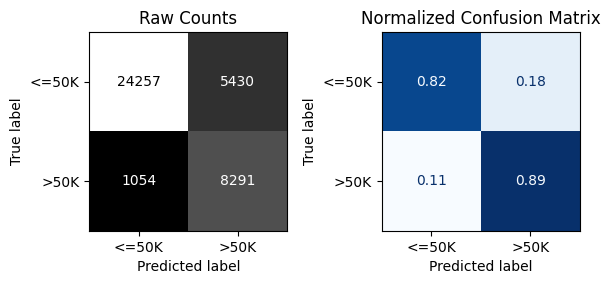


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.95      0.80      0.87      7422
        >50K       0.58      0.87      0.69      2336

    accuracy                           0.82      9758
   macro avg       0.76      0.83      0.78      9758
weighted avg       0.86      0.82      0.83      9758



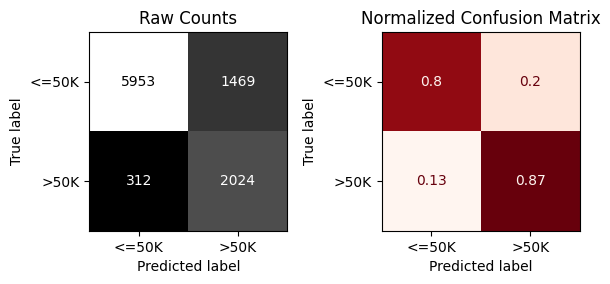

In [54]:
evaluate_classification(
    rf_model,
    X_train_processed, y_train,
    X_test_processed, y_test
)

## Permutation Importance

In this section, I use permutation importance to identify the most important features in the Random Forest model.

Permutation importance works by shuffling one feature at a time and measuring how much the model performance decreases.

If shuffling a feature causes a large drop in performance, that feature is considered important.

In [57]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, precision_score

# Precision scorer for the >50K class (matches your business case)
precision_gt50k = make_scorer(
    precision_score,
    pos_label='>50K',
    zero_division=0
)


In [58]:
# Permutation importance on the test set, using the cleaned model
perm_result = permutation_importance(
    rf_model,
    X_test_processed,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring=precision_gt50k,
    n_jobs=-1
)

In [59]:
import pandas as pd

# Map each processed column back to its original feature.
# OneHotEncoder names look like 'occupation_Exec-managerial' -> original 'occupation'.
original_features = X_train.columns  # the columns BEFORE one-hot encoding

def map_to_original(processed_col):
    # If the processed column starts with an original feature name + '_', group it there
    for feat in original_features:
        if processed_col == feat or processed_col.startswith(feat + '_'):
            return feat
    return processed_col  # fallback

# Build a table of per-column importance, then group by original feature
importance_df = pd.DataFrame({
    'processed_feature': X_test_processed.columns,
    'importance': perm_result.importances_mean
})

importance_df['original_feature'] = importance_df['processed_feature'].apply(map_to_original)

# Sum the importance of all dummy columns belonging to the same original feature
grouped_importance = (
    importance_df
    .groupby('original_feature')['importance']
    .sum()
    .sort_values(ascending=False)
)

top_10 = grouped_importance.head(10)
print(top_10)

original_feature
capital-gain       0.045069
educational-num    0.038160
occupation         0.019447
capital-loss       0.005513
workclass          0.004482
age                0.002372
hours-per-week     0.000273
native-country    -0.000677
race              -0.000790
gender            -0.006155
Name: importance, dtype: float64


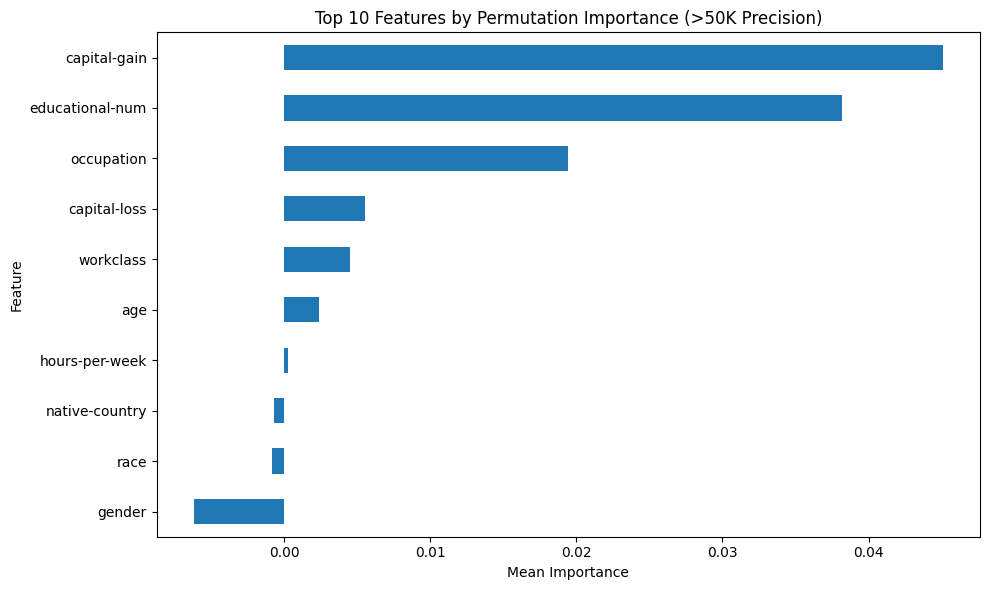

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_10.sort_values().plot(kind='barh')
plt.title('Top 10 Features by Permutation Importance (>50K Precision)')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Business Case

The goal of this project is to predict whether a person's annual income is `>50K` or `<=50K` based on demographic, education, work-related, and financial features.

This prediction can help organizations understand income patterns and identify the factors that are most related to higher income.

A possible business use case is customer segmentation for a financial institution or marketing company. For example, the model can help identify customers who are more likely to belong to a higher income group, so the organization can provide more suitable financial products, services, or marketing offers.

In this project, precision for the `>50K` class is especially important because the organization wants to make sure that people predicted as high-income are actually likely to be high-income. This helps reduce false positives and avoid targeting people with unsuitable offers.

The model should be used responsibly. The goal is not to make unfair decisions about individuals, but to analyze income-related patterns and support better decision-making.

# Model Performance Analysis
## The model achieves a recall of 0.87 for the >50K class but a precision of 0.58 on the test set. According to the business case, precision for the >50K class is the more important metric, since the goal is to avoid targeting people who are not actually high-income.
## The lower precision is an expected trade-off: balancing the classes made the model more sensitive to the minority class, which raised recall at the cost of precision. If higher precision were required by the business, the decision threshold could be raised so the model only predicts >50K when more confident, though this would reduce recall.
## For this project, the balanced result is acceptable. The F1-score of 0.69 for the >50K class reflects a reasonable balance between catching high-income individuals and keeping false positives under control.

# Explanatory Visualizations for Key Features
## In this section, I create explanatory visualizations for the two most important features identified by permutation importance: capital-gain and educational-num.
## Unlike the earlier exploratory visualizations, these are designed for a non-technical audience (such as a business stakeholder). Each chart focuses on a single clear trend, with a descriptive title, labeled axes, and a short explanation of the insight.
## The goal is to show why these two features are strong predictors of income, by clearly presenting the relationship between each feature and the target variable (income).

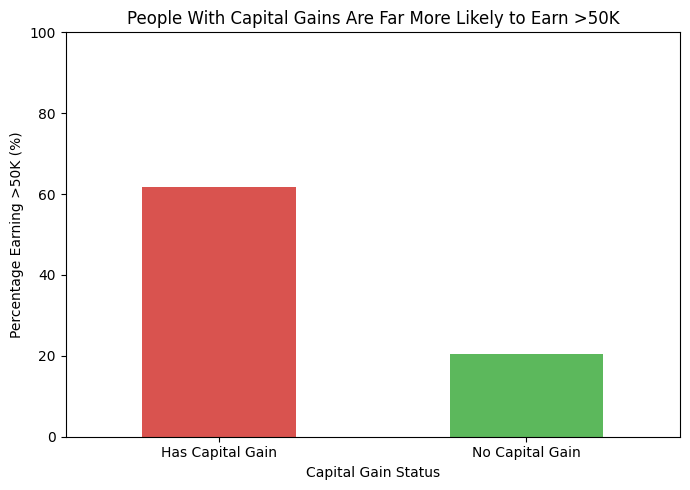

In [64]:
import matplotlib.pyplot as plt

# Create a simple group: does the person have any capital gain?
df_plot = df.copy()
df_plot['has_capital_gain'] = df_plot['capital-gain'].apply(
    lambda x: 'Has Capital Gain' if x > 0 else 'No Capital Gain'
)

# Percentage earning >50K within each group
gain_income = pd.crosstab(
    df_plot['has_capital_gain'],
    df_plot['income'],
    normalize='index'
) * 100

# Plot only the >50K percentage
plt.figure(figsize=(7, 5))
gain_income['>50K'].plot(kind='bar', color=['#d9534f', '#5cb85c'])

plt.title('People With Capital Gains Are Far More Likely to Earn >50K')
plt.xlabel('Capital Gain Status')
plt.ylabel('Percentage Earning >50K (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Insight: People who report any capital gain are far more likely to earn more than 50K per year, compared to people with no capital gain. This makes sense because capital gains usually come from investments or selling assets, which are more common among higher-income individuals. This explains why capital-gain was the most important feature in the model.

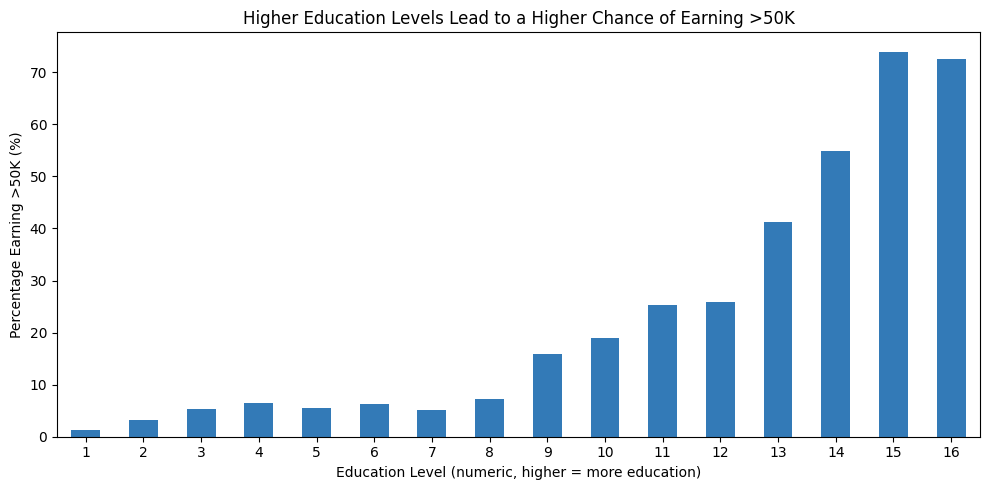

In [65]:
# Percentage earning >50K for each education level
edu_income = pd.crosstab(
    df['educational-num'],
    df['income'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 5))
edu_income['>50K'].plot(kind='bar', color='#337ab7')

plt.title('Higher Education Levels Lead to a Higher Chance of Earning >50K')
plt.xlabel('Education Level (numeric, higher = more education)')
plt.ylabel('Percentage Earning >50K (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Insight: As the education level increases, the percentage of people earning more than 50K rises steadily. People with the highest education levels are much more likely to be high earners than people with low education levels. This clear upward trend explains why educational-num was the second most important feature in the model.



In [68]:
from sklearn.decomposition import PCA

# Fit PCA on the TRAINING data only (3 components) to avoid data leakage
pca = PCA(n_components=3, random_state=42)

In [69]:
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)   # transform only, no fitting

In [70]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.17908189 0.12681446 0.11994171]
Total explained variance: 0.4258380689601594


In [71]:
import pandas as pd

pca_train_df = pd.DataFrame(
    X_train_pca,
    columns=['PCA_1', 'PCA_2', 'PCA_3'],
    index=X_train_processed.index
)

pca_test_df = pd.DataFrame(
    X_test_pca,
    columns=['PCA_1', 'PCA_2', 'PCA_3'],
    index=X_test_processed.index
)

# Concatenate the 3 PCA features with the original processed features
X_train_fe = pd.concat([X_train_processed, pca_train_df], axis=1)
X_test_fe = pd.concat([X_test_processed, pca_test_df], axis=1)

print("Shape before:", X_train_processed.shape)
print("Shape after:", X_train_fe.shape)

Shape before: (39032, 88)
Shape after: (39032, 91)


In [72]:
from sklearn.ensemble import RandomForestClassifier

rf_model_fe = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model_fe.fit(X_train_fe, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       n_estimators=300, n_jobs=-1, random_state=42)